# Manifest 통합 및 검증

**판다넘 팀 - 환경 통합 작물 질병 진행단계 분류**

각 팀원이 전처리한 작물별 zip을 한곳에 모아 manifest.csv를 통합합니다.

## 입력

팀원 전체가 처리한 결과 zip이 한 폴더에 모여 있어야 함:

```
merged_input/
├── facility_02_고추.zip      ← 팀원 A 처리
├── facility_03_단호박.zip    ← 팀원 A 처리
├── facility_04_딸기.zip      ← 팀원 B 처리
├── ...
└── outdoor_10_호박.zip       ← 팀원 E 처리
```

## 출력

- `manifest_all.csv` : 18개 그룹 통합 manifest
- 검증 결과 (그룹 누락 / 캡 위반 / 누수 등)

## 진행 순서

1. 입력 경로 확인
2. 각 zip 안의 manifest.csv 수집
3. 통합 manifest 저장
4. 검증 (그룹 / 비율 / 캡 / 누수 / 시각화)

---
## 1. 환경 설정

In [16]:
%pip install pandas

import csv
import io
import zipfile
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List

import pandas as pd

from config_pro import TRAIN_GROUPS, HELDOUT_GROUPS, MAX_PER_CLASS, RISK_NAMES, group_id

print('모듈 로드 완료')

Note: you may need to restart the kernel to use updated packages.
모듈 로드 완료


## 2. 입력 경로 지정

모든 팀원의 결과 zip이 모인 폴더를 지정하세요.

In [17]:
# ===== 자기 환경에 맞게 수정 =====
INPUT_DIR  = Path('./data')         # 팀원 zip이 모인 폴더
OUTPUT_CSV = Path('./data/manifest_all.csv')     # 통합 manifest 출력
# ================================

assert INPUT_DIR.exists(), f'❌ 입력 경로 없음: {INPUT_DIR.resolve()}'

zip_files = sorted(INPUT_DIR.glob('*.zip'))
print(f'입력 폴더: {INPUT_DIR.resolve()}')
print(f'발견된 zip: {len(zip_files)}개')
for z in zip_files:
    size_mb = z.stat().st_size / (1024**2)
    print(f'  - {z.name} ({size_mb:,.1f} MB)')

입력 폴더: /workspace/data
발견된 zip: 18개
  - facility_01_가지.zip (2,752.6 MB)
  - facility_02_고추.zip (1,890.8 MB)
  - facility_03_단호박.zip (1,606.9 MB)
  - facility_04_딸기.zip (2,031.6 MB)
  - facility_05_상추.zip (3,158.2 MB)
  - facility_06_수박.zip (2,330.9 MB)
  - facility_09_쥬키니호박.zip (1,880.5 MB)
  - facility_10_참외.zip (2,241.6 MB)
  - facility_11_토마토.zip (1,880.7 MB)
  - outdoor_01_고추.zip (1,128.7 MB)
  - outdoor_03_배추.zip (2,261.3 MB)
  - outdoor_04_애호박.zip (1,811.0 MB)
  - outdoor_05_양배추.zip (3,811.1 MB)
  - outdoor_06_오이.zip (1,901.3 MB)
  - outdoor_07_잎마름병토마토.zip (1,035.6 MB)
  - outdoor_08_콩.zip (1,761.4 MB)
  - outdoor_09_파.zip (1,448.2 MB)
  - outdoor_10_호박.zip (1,573.7 MB)


## 3. manifest 수집

각 zip 안의 `manifest.csv`를 읽어 한 DataFrame으로 합칩니다.

In [ ]:
def _decode(raw: bytes) -> str:
    """UTF-8-BOM → UTF-8 → EUC-KR 순으로 디코딩 시도."""
    for enc in ("utf-8-sig", "utf-8", "euc-kr", "cp949"):
        try:
            return raw.decode(enc)
        except (UnicodeDecodeError, LookupError):
            continue
    return raw.decode("utf-8", errors="replace")


def read_manifest_from_zip(zip_path: Path) -> List[Dict]:
    """zip 안의 manifest.csv 읽기 (쉼표/탭 구분자 자동 감지)."""
    rows = []
    with zipfile.ZipFile(zip_path, 'r') as zf:
        manifest_name = None
        for entry in zf.namelist():
            if entry.endswith('/manifest.csv') or entry == 'manifest.csv':
                manifest_name = entry
                break
        if not manifest_name:
            return rows
        with zf.open(manifest_name) as f:
            raw = f.read()
    data = _decode(raw)

    # 쉼표 → 탭 순으로 시도, 컬럼이 2개 이상이어야 정상
    for delim in (',', '\t'):
        reader = csv.DictReader(io.StringIO(data), delimiter=delim)
        rows = list(reader)
        if reader.fieldnames and len(reader.fieldnames) > 1:
            break

    return rows

all_rows = []
for zf in zip_files:
    rows = read_manifest_from_zip(zf)
    print(f'  {zf.name}: {len(rows):,}행')
    all_rows.extend(rows)

df = pd.DataFrame(all_rows)
print(f'\n통합 결과: {len(df):,}행')
print(f'컬럼: {list(df.columns)}')
df.head()

## 4. 데이터 타입 정규화

CSV에서 읽으면 모두 문자열이라 숫자 컬럼을 타입 변환.

In [20]:
for col in ['crop_code', 'disease', 'risk', 'grow']:
    df[col] = df[col].astype(int)
df['is_aug'] = df['is_aug'].map({'True': True, 'False': False, True: True, False: False})
print('타입 변환 완료')
print(df.dtypes)

ValueError: cannot convert float NaN to integer

---
## 5. 검증

다음 항목들을 자동으로 검사합니다:

1. 그룹 존재 확인 (18개 모두 있는지)
2. split별 분포
3. 학습 그룹 train/val/test 비율
4. 그룹별 train 양 (캡 5000 위반 여부)
5. 원본 ID 누수 검사 (가장 중요)

### 5.1 그룹 존재 확인

In [17]:
expected_ids = set(group_id(e, c) for e, c in TRAIN_GROUPS + HELDOUT_GROUPS)
found_ids = set(df['group_id'].unique())

missing = expected_ids - found_ids
extra   = found_ids - expected_ids

print(f'기대 그룹: {len(expected_ids)} / 발견 그룹: {len(found_ids)}')
if missing:
    print(f'\n❌ 누락 그룹 {len(missing)}개:')
    for g in sorted(missing):
        print(f'  - {g}')
if extra:
    print(f'\n⚠ 알 수 없는 그룹 {len(extra)}개:')
    for g in sorted(extra):
        print(f'  - {g}')
if not missing and not extra:
    print('\n✓ 모든 그룹 정상')

기대 그룹: 18 / 발견 그룹: 14

❌ 누락 그룹 4개:
  - facility_01_가지
  - facility_02_고추
  - outdoor_01_고추
  - outdoor_04_애호박


### 5.2 split별 분포

In [18]:
split_count = df['split'].value_counts()
total = len(df)
print('전체 split 분포:')
for s, n in split_count.items():
    print(f'  {s:20s}: {n:>7,} ({n/total*100:5.1f}%)')

print('\n학습 그룹의 train/val/test 비율:')
train_g = df[df['group_type']=='train_group']
in_split = train_g[train_g['split'].isin(['train','val','test'])]['split'].value_counts()
in_total = in_split.sum()
for s in ['train','val','test']:
    n = in_split.get(s, 0)
    print(f'  {s}: {n:>7,} ({n/in_total*100:5.1f}%)')

전체 split 분포:
  train               : 150,378 ( 36.4%)
  heldout             : 124,934 ( 30.3%)
  test                :  44,679 ( 10.8%)
  val                 :  44,547 ( 10.8%)
  external_val        :  35,897 (  8.7%)
  heldout_external    :  12,425 (  3.0%)

학습 그룹의 train/val/test 비율:
  train: 150,378 ( 62.8%)
  val:  44,547 ( 18.6%)
  test:  44,679 ( 18.6%)


### 5.3 클래스(risk) 분포

In [19]:
print('train split의 risk별 분포:')
train_rows = df[(df['group_type']=='train_group') & (df['split']=='train')]
for risk in [0,1,2,3]:
    n = (train_rows['risk']==risk).sum()
    print(f'  {RISK_NAMES[risk]} (risk={risk}): {n:>6,} ({n/len(train_rows)*100:5.1f}%)')

train split의 risk별 분포:
  정상 (risk=0): 41,925 ( 27.9%)
  초기 (risk=1): 42,133 ( 28.0%)
  중기 (risk=2): 40,038 ( 26.6%)
  말기 (risk=3): 26,282 ( 17.5%)


### 5.4 그룹별 train 양 (캡 5000 위반 여부)

In [21]:
print(f'그룹×클래스별 train 양 (캡 {MAX_PER_CLASS}):\n')
pivot = train_rows.pivot_table(
    index='group_id', columns='risk', values='file', aggfunc='count', fill_value=0
).rename(columns=RISK_NAMES)
pivot['total'] = pivot.sum(axis=1)
pivot['max']   = pivot[list(RISK_NAMES.values())].max(axis=1)
pivot['캡위반'] = pivot['max'].apply(lambda x: '❌' if x > MAX_PER_CLASS else '✓')
print(pivot.to_string())

violations = pivot[pivot['max'] > MAX_PER_CLASS]
if len(violations) > 0:
    print(f'\n❌ 캡 위반 그룹: {len(violations)}개')
else:
    print(f'\n✓ 모든 그룹 캡 준수')

그룹×클래스별 train 양 (캡 5000):

risk                 정상    초기    중기    말기  total   max 캡위반
group_id                                                  
facility_03_단호박    1925  4455  4169  2057  12606  4455   ✓
facility_04_딸기     5000  5000  3806  2662  16468  5000   ✓
facility_05_상추     5000  5000  5000  5000  20000  5000   ✓
facility_09_쥬키니호박  5000  4281  4479  3748  17508  5000   ✓
facility_11_토마토    5000  3853  5000  2167  16020  5000   ✓
outdoor_03_배추      5000  5000  4912  2640  17552  5000   ✓
outdoor_06_오이      5000  4544  2672  1536  13752  5000   ✓
outdoor_08_콩       5000  5000  5000  1472  16472  5000   ✓
outdoor_09_파       5000  5000  5000  5000  20000  5000   ✓

✓ 모든 그룹 캡 준수


### 5.5 원본 ID 누수 검사 (가장 중요)

같은 `original_id` 가 train/val/test 여러 split에 동시에 있으면 데이터 누수.  
(external_val, heldout 등은 어차피 외부 평가이므로 검사 대상 X)

In [22]:
tg = df[(df['group_type']=='train_group') & df['split'].isin(['train','val','test'])]
multi = tg.groupby('original_id')['split'].nunique()
leaked = multi[multi > 1]

if len(leaked) > 0:
    print(f'❌ 누수 발견: {len(leaked)}개 원본 ID')
    print('\n예시 (최대 10개):')
    for oid in leaked.index[:10]:
        splits = tg[tg['original_id']==oid]['split'].unique()
        print(f'  {oid}: {splits}')
else:
    print('✓ 누수 없음 (모든 원본이 단일 split)')
    print(f'  검사한 원본 ID: {len(multi):,}개')

✓ 누수 없음 (모든 원본이 단일 split)
  검사한 원본 ID: 85,868개


---
## 6. 시각화

분포를 그래프로 확인.


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/tmp/ipykernel_20977/3550758212.py:34: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20977/355

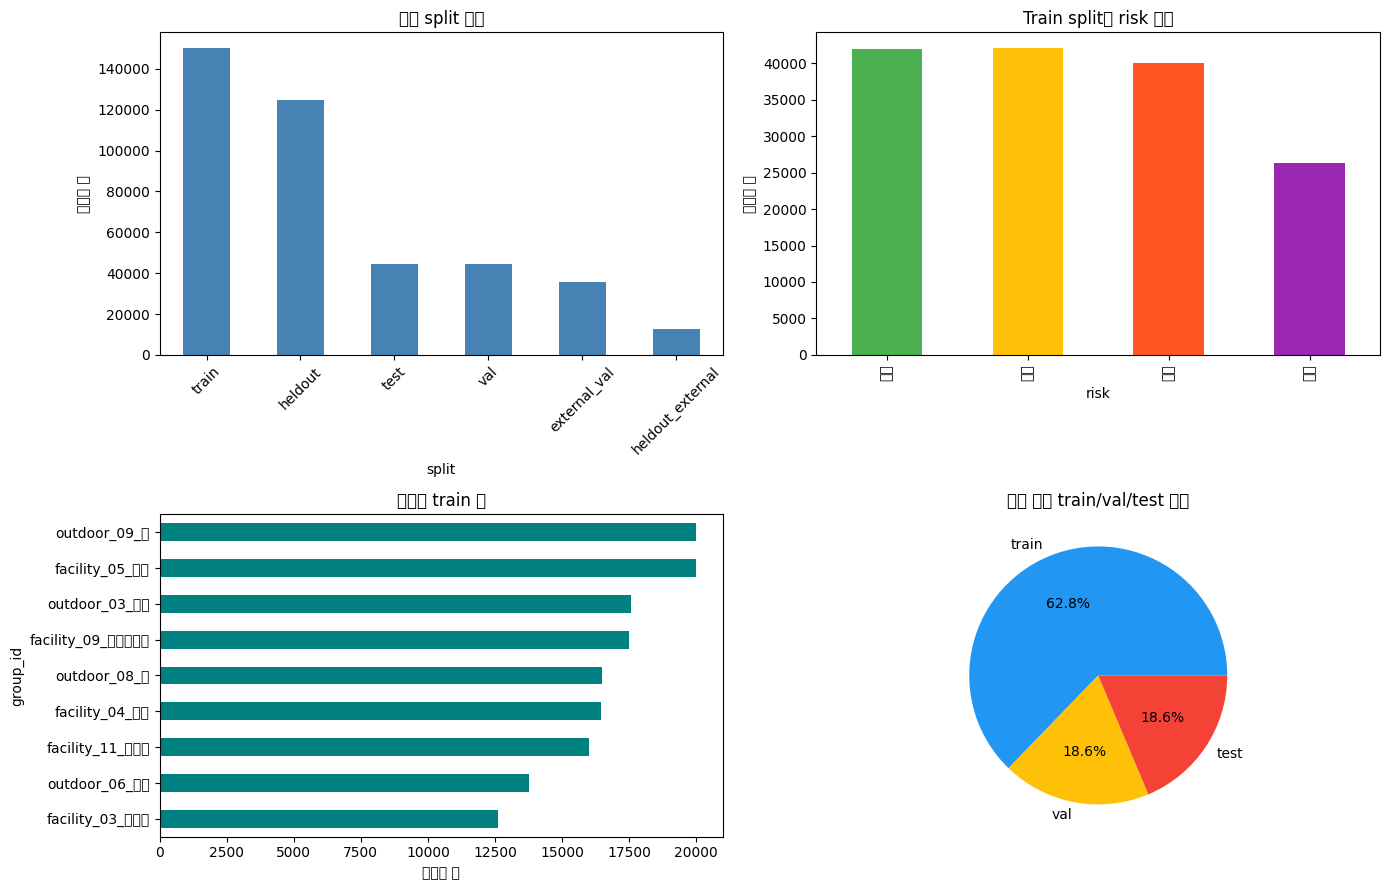

In [23]:
%pip install matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. 전체 split 분포
df['split'].value_counts().plot.bar(ax=axes[0][0], color='steelblue')
axes[0][0].set_title('전체 split 분포')
axes[0][0].set_ylabel('이미지 수')
axes[0][0].tick_params(axis='x', rotation=45)

# 2. train split의 risk 분포
train_rows['risk'].map(RISK_NAMES).value_counts().reindex(
    list(RISK_NAMES.values())
).plot.bar(ax=axes[0][1], color=['#4CAF50','#FFC107','#FF5722','#9C27B0'])
axes[0][1].set_title('Train split의 risk 분포')
axes[0][1].set_ylabel('이미지 수')

# 3. 그룹별 train 양
group_total = train_rows.groupby('group_id').size().sort_values()
group_total.plot.barh(ax=axes[1][0], color='teal')
axes[1][0].set_title('그룹별 train 양')
axes[1][0].set_xlabel('이미지 수')

# 4. 학습 그룹의 train/val/test 비율 (파이)
in_split.reindex(['train','val','test']).plot.pie(
    ax=axes[1][1], autopct='%.1f%%', colors=['#2196F3','#FFC107','#F44336']
)
axes[1][1].set_title('학습 그룹 train/val/test 비율')
axes[1][1].set_ylabel('')

plt.tight_layout()
plt.show()

---
## 7. 통합 manifest 저장

검증 통과했으면 저장.

In [24]:
df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
size_mb = OUTPUT_CSV.stat().st_size / (1024**2)
print(f'✓ 저장 완료: {OUTPUT_CSV.resolve()} ({size_mb:.1f} MB, {len(df):,}행)')

✓ 저장 완료: /workspace/data/manifest_all.csv (52.7 MB, 412,860행)


---
## 8. Runpod 업로드 준비

다음을 Runpod에 업로드:

1. `manifest_all.csv` (이 노트북 결과)
2. 모든 그룹 zip 파일 (입력으로 받은 18개)

Runpod에서 학습 시작 전:
```bash
# 1. 데이터 다운로드
# 2. zip 압축 해제 → 모든 image 폴더 + manifest_all.csv 준비
# 3. dataset.py가 manifest_all.csv 기반으로 동작
```

## 9. 다음 단계

- [ ] 검증 모두 통과했나요? (그룹 18개 / 누수 0 / 캡 위반 0)
- [ ] manifest_all.csv 저장됐나요?
- [ ] Runpod에 모든 zip + manifest 업로드 했나요?
- [ ] dataset.py 를 manifest 기반으로 동작하도록 수정했나요? (다음 PR)